In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load the CSV ---
file_path = "./esa_all_basins_area_timeseries.csv"
df = pd.read_csv(file_path, delimiter=';', decimal=',')

# --- Convert area columns from m² to km² ---
df.iloc[:, 2:] = df.iloc[:, 2:] / 1_000_000

/var/folders/s0/9nvdkxfx2y9f04nct7n3l8c40000gn/T/ipykernel_2844/2806216479.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       2511.99
1       2171.52
2      52134.93
3      22769.73
4       4580.91
5        712.35
6     165298.32
7         13.05
8       2123.64
9       2349.54
10    162348.12
11    118602.45
12     20850.84
13     13302.99
14    100099.17
15       227.25
16     12997.35
17      6409.71
18    112786.92
19    150991.83
20     38943.36
21      2459.52
22      7103.88
23     76156.02
24       391.41
25      1821.60
26      1479.69
27     47362.68
28     27347.22
29      4672.17
30       775.53
31     47735.28
32        25.83
Name: 1992, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, 2:] = df.iloc[:, 2:] / 1_000_000
/var/folders/s0/9nvdkxfx2y9f04nct7n3l8c40000gn/T/ipykernel_2844/2806216479.py:10: FutureWarning: Setting an ite

#### PLOT GLOBAL STATISTICS FOR A SINGLE CLASS

In [3]:
def plot_land_cover_changes_single(class_name, start_year=1995, end_year=2022, 
                                   title_fontsize=14, label_fontsize=12):
    # Define a color ramp (mapping of each class to a specific color)
    color_map = {
        'Shrubland': '#8b4513',  # SaddleBrown
        'Grassland': '#32cd32',  # LimeGreen
        'Cropland': '#ffd700',   # Gold
        'Wetland': '#4682b4',    # SteelBlue
        'Lichens and mosses': '#a9cda9',  # LightGreen
        'Bareland': '#c2b280',   # Khaki
        'Built-up': '#808080',   # Gray
        'Water': '#1e90ff',      # DodgerBlue
        'Permanent ice and Snow': '#b0c4de',  # LightSteelBlue
        'Forest': '#006400',     # DarkGreen
        'No data': '#ffffff'     # White (no data)
    }

    years = df.columns[2:].astype(int)
    if start_year not in years.values or end_year not in years.values:
        print("Start or end year not in available data.")
        return

    row = df[df['Land cover class'] == class_name]
    if row.empty:
        print(f"Class '{class_name}' not found.")
        return  

    area = row.iloc[0, 2:].values
    year_idx = years.get_indexer_for([start_year, end_year])
    start_idx, end_idx = year_idx[0], year_idx[1]
    
    selected_years = years[start_idx:end_idx + 1]
    selected_area = area[start_idx:end_idx + 1]

    yearly_diff = np.diff(selected_area)
    cumulative_gain = np.sum(np.where(yearly_diff > 0, yearly_diff, 0))
    cumulative_loss = np.sum(np.where(yearly_diff < 0, -yearly_diff, 0))
    cumulative_gain_series = np.cumsum(np.where(yearly_diff > 0, yearly_diff, 0))
    cumulative_loss_series = np.cumsum(np.where(yearly_diff < 0, -yearly_diff, 0))

    class_color = color_map.get(class_name, '#000000')

    fig, axs = plt.subplots(3, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 2, 2]})

    axs[0].plot(selected_years, selected_area, marker='o', color=class_color)
    axs[0].set_title(f"Net Area Balance (km²): {class_name}", fontsize=title_fontsize)
    axs[0].set_xlabel("Year", fontsize=label_fontsize)
    axs[0].set_ylabel("Area (km²)", fontsize=label_fontsize)
    axs[0].grid(True)

    axs[1].plot(selected_years[1:], cumulative_gain_series, marker='^', label='Cumulative Gain', color=class_color, linestyle='-')
    axs[1].plot(selected_years[1:], cumulative_loss_series, marker='v', label='Cumulative Loss', color=class_color, linestyle='--')
    axs[1].axhline(0, color='gray', linestyle='--')
    axs[1].set_title(f"Cumulative Gain/Loss (km²): {class_name}", fontsize=title_fontsize)
    axs[1].set_xlabel("Year", fontsize=label_fontsize)
    axs[1].set_ylabel("Cumulative Change (km²)", fontsize=label_fontsize)
    axs[1].grid(True)
    axs[1].legend()

    axs[2].bar(selected_years[1:], yearly_diff, color=class_color)
    axs[2].axhline(0, color='gray', linestyle='--')
    axs[2].set_title(f"Year-by-Year Area Variation (km²): {class_name}", fontsize=title_fontsize)
    axs[2].set_xlabel("Year", fontsize=label_fontsize)
    axs[2].set_ylabel("Yearly Change (km²)", fontsize=label_fontsize)
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

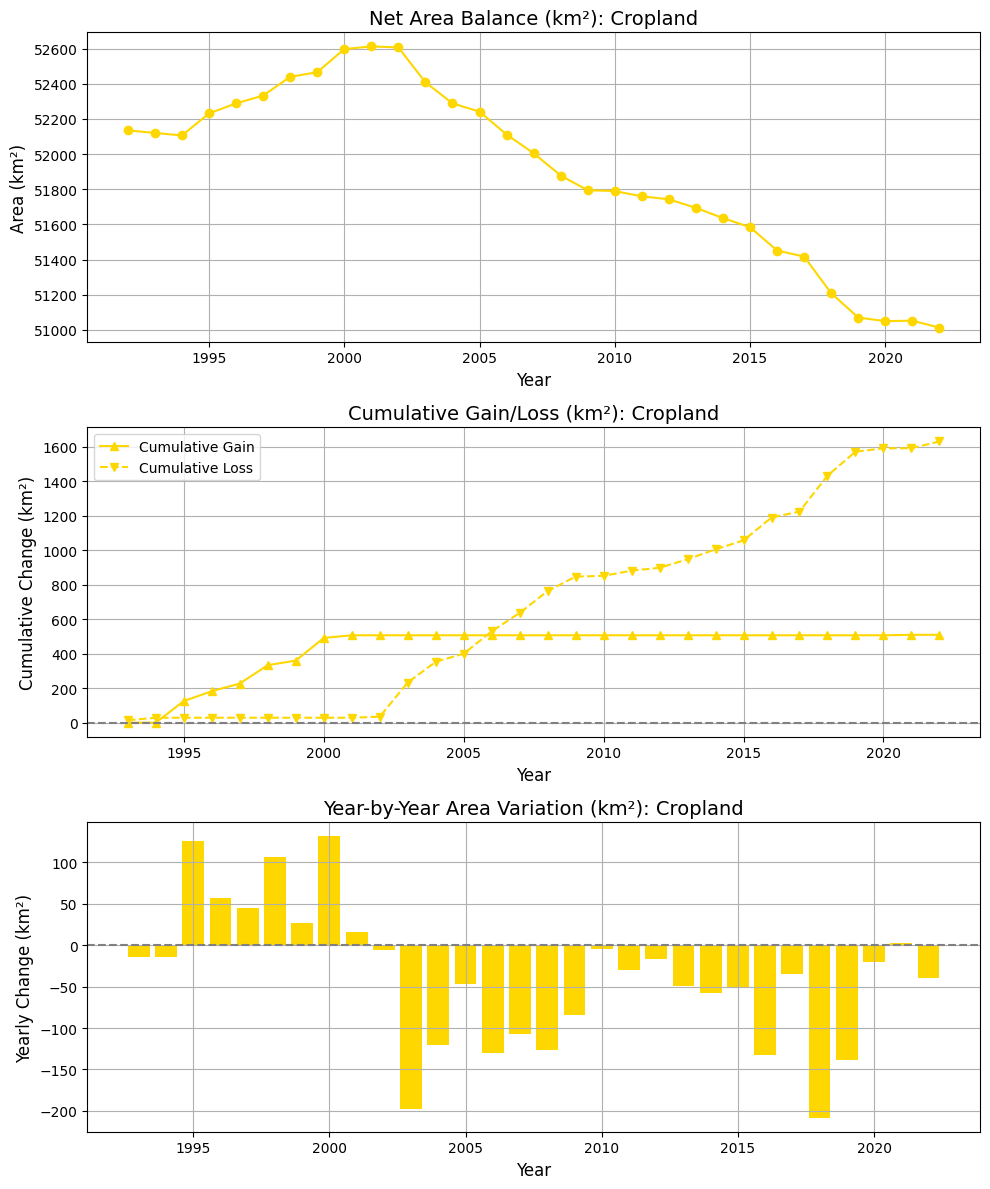

In [4]:
# --- Example usage single class---
plot_land_cover_changes_single("Cropland", start_year=1992, end_year=2022, title_fontsize=14, label_fontsize=12) 

#### PLOT GLOBAL STATISTICS FOR A MULTIPLE CLASSES

In [5]:
def plot_land_cover_change_multiple(class_names, start_year=1995, end_year=2022, title_fontsize=14, label_fontsize=12):
    # Define a color ramp (mapping of each class to a specific color)
    color_map = {
        'Shrubland': '#8b4513',  # SaddleBrown
        'Grassland': '#32cd32',  # LimeGreen
        'Cropland': '#ffd700',   # Gold
        'Wetland': '#4682b4',    # SteelBlue
        'Lichens and mosses': '#a9cda9',  # LightGreen
        'Bareland': '#c2b280',   # Khaki
        'Built-up': '#808080',   # Gray
        'Water': '#1e90ff',      # DodgerBlue
        'Permanent ice and Snow': '#b0c4de',  # LightSteelBlue
        'Forest': '#006400',     # DarkGreen
        'No data': '#ffffff'     # White (no data)
    }

    years = df.columns[2:].astype(int)
    
    if start_year not in years.values or end_year not in years.values:
        print("Start or end year not in available data.")
        return

    selected_areas = []
    yearly_diffs = []
    cumulative_gain_series_list = []
    cumulative_loss_series_list = []
    
    for idx, class_name in enumerate(class_names):
        if class_name not in color_map:
            print(f"Class '{class_name}' not found in color map.")
            return
        
        row = df[df['Land cover class'] == class_name]
        if row.empty:
            print(f"Class '{class_name}' not found.")
            return

        area = row.iloc[0, 2:].values
        year_idx = years.get_indexer_for([start_year, end_year])
        start_idx, end_idx = year_idx[0], year_idx[1]
        
        selected_years = years[start_idx:end_idx + 1]
        selected_area = area[start_idx:end_idx + 1]

        yearly_diff = np.diff(selected_area)
        cumulative_gain_series = np.cumsum(np.where(yearly_diff > 0, yearly_diff, 0))
        cumulative_loss_series = np.cumsum(np.where(yearly_diff < 0, -yearly_diff, 0))

        selected_areas.append(selected_area)
        yearly_diffs.append(yearly_diff)
        cumulative_gain_series_list.append(cumulative_gain_series)
        cumulative_loss_series_list.append(cumulative_loss_series)

    fig, axs = plt.subplots(3, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 2, 2]})

    # 1. Area Time Series
    for idx, class_name in enumerate(class_names):
        axs[0].plot(selected_years, selected_areas[idx], marker='o', label=class_name, color=color_map[class_name])
    axs[0].set_title(f"Net Area Balance (km²): {' vs '.join(class_names)}", fontsize=title_fontsize)
    axs[0].set_xlabel("Year", fontsize=label_fontsize)
    axs[0].set_ylabel("Area (km²)", fontsize=label_fontsize)
    axs[0].grid(True)
    axs[0].legend()

    # 2. Cumulative Gain and Loss
    markers = ['^', 'v']
    for idx, class_name in enumerate(class_names):
        axs[1].plot(selected_years[1:], cumulative_gain_series_list[idx], 
                    marker=markers[0], label=f'Cumulative Gain - {class_name}', color=color_map[class_name], linestyle='-')
        axs[1].plot(selected_years[1:], cumulative_loss_series_list[idx], 
                    marker=markers[1], label=f'Cumulative Loss - {class_name}', color=color_map[class_name], linestyle='--')
    
    axs[1].axhline(0, color='gray', linestyle='--')
    axs[1].set_title(f"Cumulative Gain/Loss (km²): {' vs '.join(class_names)}", fontsize=title_fontsize)
    axs[1].set_xlabel("Year", fontsize=label_fontsize)
    axs[1].set_ylabel("Cumulative Change (km²)", fontsize=label_fontsize)
    axs[1].grid(True)
    axs[1].legend()

    # 3. Year-by-Year Variation
    for idx, class_name in enumerate(class_names):
        axs[2].bar(selected_years[1:], yearly_diffs[idx], width=0.8, alpha=0.6, label=class_name, color=color_map[class_name])
    axs[2].axhline(0, color='gray', linestyle='--')
    axs[2].set_title(f"Yearly Area Change (km²): {' vs '.join(class_names)}", fontsize=title_fontsize)
    axs[2].set_xlabel("Year", fontsize=label_fontsize)
    axs[2].set_ylabel("Yearly Change (km²)", fontsize=label_fontsize)
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

In [6]:
# this is for staked barplot
def plot_land_cover_change_multiple(class_names, start_year=1995, end_year=2022, title_fontsize=14, label_fontsize=12):
    # Define a color ramp (mapping of each class to a specific color)
    color_map = {
        'Shrubland': '#8b4513',  # SaddleBrown
        'Grassland': '#32cd32',  # LimeGreen
        'Cropland': '#ffd700',   # Gold
        'Wetland': '#4682b4',    # SteelBlue
        'Lichens and mosses': '#a9cda9',  # LightGreen
        'Bareland': '#c2b280',   # Khaki
        'Built-up': '#808080',   # Gray
        'Water': '#1e90ff',      # DodgerBlue
        'Permanent ice and Snow': '#b0c4de',  # LightSteelBlue
        'Forest': '#006400',     # DarkGreen
        'No data': '#ffffff'     # White (no data)
    }

    # Years from columns (assumed like '1995','1996',...)
    years = df.columns[2:].astype(int)

    if start_year not in years.values or end_year not in years.values:
        print("Start or end year not in available data.")
        return

    # Determine the selected year range once
    year_idx = years.get_indexer_for([start_year, end_year])
    start_idx, end_idx = year_idx[0], year_idx[1]
    selected_years = years[start_idx:end_idx + 1]

    yearly_diffs = []
    cumulative_gain_series_list = []
    cumulative_loss_series_list = []

    for class_name in class_names:
        if class_name not in color_map:
            print("Class '" + class_name + "' not found in color map.")
            return

        row = df[df['Land cover class'] == class_name]
        if row.empty:
            print("Class '" + class_name + "' not found.")
            return

        # Coerce area values to float to avoid dtype('O')
        area_series = pd.to_numeric(row.iloc[0, 2:], errors='coerce')
        area = area_series.values.astype(float)

        # Slice years and coerce NaNs to 0
        selected_area = area[start_idx:end_idx + 1]
        selected_area = np.nan_to_num(selected_area, nan=0.0, posinf=None, neginf=None).astype(float)

        # Yearly differences and cumulative gain/loss
        yearly_diff = np.diff(selected_area).astype(float)
        gains = np.where(yearly_diff > 0, yearly_diff, 0.0)
        losses = np.where(yearly_diff < 0, -yearly_diff, 0.0)

        cumulative_gain_series = np.cumsum(gains).astype(float)
        cumulative_loss_series = np.cumsum(losses).astype(float)

        yearly_diffs.append(yearly_diff)
        cumulative_gain_series_list.append(cumulative_gain_series)
        cumulative_loss_series_list.append(cumulative_loss_series)

    # 2 subplots only: (1) cumulative gain/loss, (2) stacked yearly change
    fig, axs = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 2]})

    # 1) Cumulative Gain and Loss
    markers = ['^', 'v']
    for idx, class_name in enumerate(class_names):
        axs[0].plot(selected_years[1:], cumulative_gain_series_list[idx],
                    marker=markers[0], label='Cumulative Gain - ' + class_name,
                    color=color_map[class_name], linestyle='-')
        axs[0].plot(selected_years[1:], cumulative_loss_series_list[idx],
                    marker=markers[1], label='Cumulative Loss - ' + class_name,
                    color=color_map[class_name], linestyle='--')

    axs[0].axhline(0, color='gray', linestyle='--')
    axs[0].set_title("Cumulative Gain/Loss (km²): " + " vs ".join(class_names), fontsize=title_fontsize)
    axs[0].set_xlabel("Year", fontsize=label_fontsize)
    axs[0].set_ylabel("Cumulative Change (km²)", fontsize=label_fontsize)
    axs[0].grid(True)
    axs[0].legend()

    # 2) Year-by-Year Variation (STACKED, pos up / neg down)
    years_for_bars = selected_years[1:]
    n_years = len(years_for_bars)

    bottom_pos = np.zeros(n_years, dtype=float)
    bottom_neg = np.zeros(n_years, dtype=float)

    for idx, class_name in enumerate(class_names):
        diffs = np.asarray(yearly_diffs[idx], dtype=float)

        # positive part
        pos = np.where(diffs > 0, diffs, 0.0).astype(float)
        axs[1].bar(years_for_bars, pos, width=0.8, bottom=bottom_pos,
                   alpha=0.85, label=class_name, color=color_map[class_name])
        bottom_pos = bottom_pos + pos

        # negative part (stack downward)
        neg = np.where(diffs < 0, diffs, 0.0).astype(float)  # negative values kept negative
        axs[1].bar(years_for_bars, neg, width=0.8, bottom=bottom_neg,
                   alpha=0.85, label="_nolegend_", color=color_map[class_name])
        bottom_neg = bottom_neg + neg

    axs[1].axhline(0, color='gray', linestyle='--')
    axs[1].set_title("Yearly Area Change (km²): " + " vs ".join(class_names), fontsize=title_fontsize)
    axs[1].set_xlabel("Year", fontsize=label_fontsize)
    axs[1].set_ylabel("Yearly Change (km²)", fontsize=label_fontsize)
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [7]:
# Retrieve all unique land cover classes from the dataframe
class_names = df['Land cover class'].unique()
class_names

array(['Bareland', 'Built-up', 'Cropland', 'Forest', 'Grassland',
       'Shrubland', 'Water', 'Wetland', 'Permanent ice and snow'],
      dtype=object)

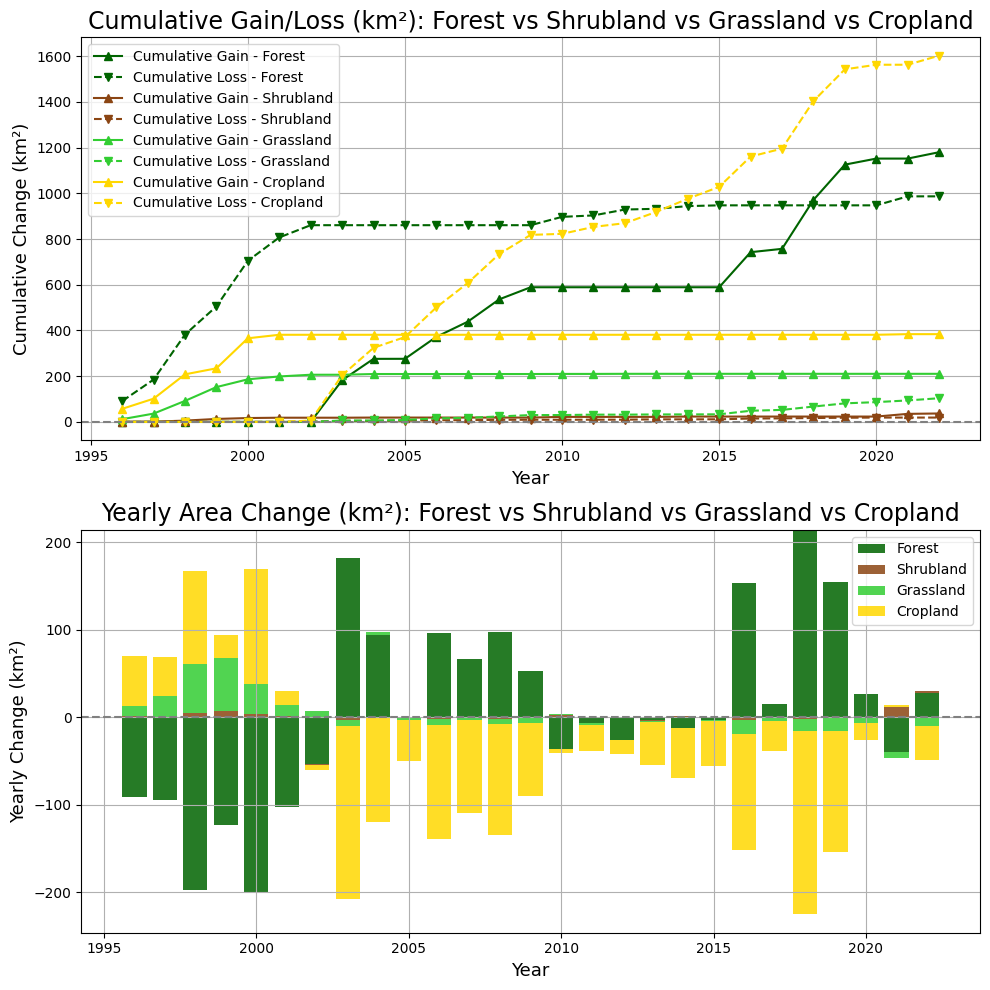

In [8]:
# --- Example usage multiple classes---
plot_land_cover_change_multiple(['Forest', 'Shrubland','Grassland','Cropland'], start_year=1995, end_year=2022, title_fontsize=17, label_fontsize=13)

#### PLOT SUMMARY AREA CHANGES FOR MULTIPLE CLASSES

In [9]:
def summarize_land_cover_changes(classes, start_year=1992, end_year=2022):
    years = df.columns[2:].astype(int)
    if start_year not in years.values or end_year not in years.values:
        return "Start or end year not in available data."

    summaries = []

    for class_name in classes:
        row = df[df['Land cover class'] == class_name]
        if row.empty:
            summaries.append(f"Class '{class_name}' not found.")
            continue

        area = row.iloc[0, 2:].values
        year_idx = years.get_indexer_for([start_year, end_year])
        start_idx, end_idx = year_idx[0], year_idx[1]
        selected_area = area[start_idx:end_idx + 1]
        yearly_diff = np.diff(selected_area)
        cumulative_gain = np.sum(np.where(yearly_diff > 0, yearly_diff, 0))
        cumulative_loss = np.sum(np.where(yearly_diff < 0, -yearly_diff, 0))
        
        # Net balance is calculated as cumulative gain minus cumulative loss{
        net_balance = cumulative_gain - cumulative_loss

        summary = {
            "Class": class_name,
            "Start Year": start_year,
            "End Year": end_year,
            "Cumulative Gain (km²)": round(cumulative_gain, 2),
            "Cumulative Loss (km²)": round(cumulative_loss, 2),
            "Net Balance (km²)": round(net_balance, 2)  # Add Net Balance to summary
        }

        summaries.append(summary)

    # Print summaries for each class
    for summary in summaries:
        if isinstance(summary, dict):
            print(f"Summary of Area Change for '{summary['Class']}' ({start_year}-{end_year}):")
            for k, v in summary.items():
                if k != 'Class':  # Exclude class name from the individual summary printout
                    print(f"  {k}: {v}")
        else:
            print(summary)  # For classes not found

In [10]:
# --- Example usage ---
summarize_land_cover_changes(['Forest', 'Shrubland','Grassland','Cropland'], start_year=1995, end_year=2015)

Summary of Area Change for 'Forest' (1995-2015):
  Start Year: 1995
  End Year: 2015
  Cumulative Gain (km²): 589.14
  Cumulative Loss (km²): 947.52
  Net Balance (km²): -358.38
Summary of Area Change for 'Shrubland' (1995-2015):
  Start Year: 1995
  End Year: 2015
  Cumulative Gain (km²): 23.4
  Cumulative Loss (km²): 11.43
  Net Balance (km²): 11.97
Summary of Area Change for 'Grassland' (1995-2015):
  Start Year: 1995
  End Year: 2015
  Cumulative Gain (km²): 210.42
  Cumulative Loss (km²): 33.21
  Net Balance (km²): 177.21
Summary of Area Change for 'Cropland' (1995-2015):
  Start Year: 1995
  End Year: 2015
  Cumulative Gain (km²): 381.24
  Cumulative Loss (km²): 1028.43
  Net Balance (km²): -647.19
